
# Data Tidying and Transformation Project

This project demonstrates data cleaning and analysis using Python and pandas.

Three datasets were analyzed:

1. Sharfin’s Video Game Player Score Data
2. Anas’ Domestic Box Office Revenue by Year
3. My Wildlife Observation Data

Each dataset contained inconsistencies that needed cleaning and transformation before analysis.



In [1]:
import pandas as pd
import numpy as np

## Dataset 1: Video Game Player Scores

This dataset contains player scores, checkpoints, and playtime values.

Data quality issues included:
- Duplicate rows
- Invalid negative scores
- Missing values
- Corrupted playtime values

The following steps clean and prepare the data for analysis.


In [2]:
df1 = pd.read_csv("dataset1_game_scores.csv")
df1

,Username,Score,Checkpoints,Playtime
0,GL!TCH,-1.0,-1,##############################################...
1,Player_One,99.0,1,5:20
2,PlayerTwo,92.0,4,6:40
3,Player3,85.0,2,5:30
4,Player4,NaN,3,NaN
5,Player4,NaN,3,NaN


In [3]:
df1 = df1.drop_duplicates()

df1.loc[df1["Score"] < 0, "Score"] = np.nan

df1["Playtime"] = pd.to_datetime(df1["Playtime"], format="%M:%S", errors="coerce")

df1["Playtime_seconds"] = df1["Playtime"].dt.minute * 60 + df1["Playtime"].dt.second

df1 = df1.dropna(subset=["Score"])

df1

/tmp/ipykernel_438/3413491642.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Playtime"] = pd.to_datetime(df1["Playtime"], format="%M:%S", errors="coerce")
/tmp/ipykernel_438/3413491642.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Playtime_seconds"] = df1["Playtime"].dt.minute * 60 + df1["Playtime"].dt.second


,Username,Score,Checkpoints,Playtime,Playtime_seconds
1,Player_One,99.0,1,1900-01-01 00:05:20,320.0
2,PlayerTwo,92.0,4,1900-01-01 00:06:40,400.0
3,Player3,85.0,2,1900-01-01 00:05:30,330.0


In [4]:
print("Average Score:", df1["Score"].mean())

print("Highest Scoring Player:")
print(df1.loc[df1["Score"].idxmax()])

Average Score: 92.0
Highest Scoring Player:
Username                     Player_One
Score                              99.0
Checkpoints                           1
Playtime            1900-01-01 00:05:20
Playtime_seconds                  320.0
Name: 1, dtype: object


## Dataset 2: Domestic Box Office Revenue

This dataset records yearly domestic box office revenue along with the number of film releases and the average revenue per film.

Issues in the dataset:
- Currency symbols in numeric columns
- Percentages stored as text
- Numbers containing commas

These fields must be converted to numeric values before analysis.

In [5]:
df2 = pd.read_csv("dataset2_box_office.csv")
df2.head()


,Year,Total_Gross,Percent_Change,Releases,Average_Gross,Top_Movie
0,2026,$1190636943,NaN,168,$7087124,Avatar: Fire and Ash
1,2025,$8655387700,1.0,668,$12957167,A Minecraft Movie
2,2024,$8571249443,-3.8,677,$12660634,Inside Out 2
3,2023,$8907716802,20.9,592,$15046818,Barbie
4,2022,$7369914732,64.4,502,$14681105,Top Gun: Maverick


In [12]:
df2["Total_Gross"] = df2["Total_Gross"].replace(r'[\$,]', '', regex=True).astype(float)
df2["Average_Gross"] = df2["Average_Gross"].replace(r'[\$,]', '', regex=True).astype(float)

df2["Percent_Change"] = df2["Percent_Change"].astype(str).str.replace('%', '', regex=False)
df2["Percent_Change"] = pd.to_numeric(df2["Percent_Change"], errors="coerce")

In [13]:
print("Highest Grossing Year")
print(df2.loc[df2["Total_Gross"].idxmax()])

Highest Grossing Year
Year                       2018
Total_Gross       11892160011.0
Percent_Change              7.4
Releases                    993
Average_Gross        11975991.0
Top_Movie         Black Panther
Name: 8, dtype: object


<Axes: title={'center': 'Box Office Revenue by Year'}, xlabel='Year'>

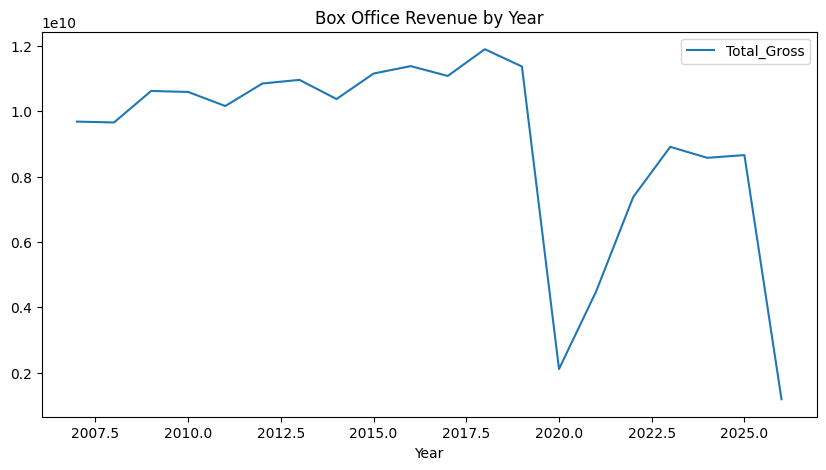

In [14]:
df2.sort_values("Year").plot(x="Year", y="Total_Gross", figsize=(10,5), title="Box Office Revenue by Year")

## Dataset 3: Wildlife Observation Data

This dataset records species, habitat, body measurements, geographic coordinates, and observation dates.

Problems identified:
- Mixed measurement units
- Combined coordinate values
- Inconsistent date formats

The data must be standardized before analysis.

## Cleaning Challenges and Observations

While working with Dataset 3, I ran into a few issues alot of trial and error:

- The weight column did not contain the actual weight; instead, the “habitat” column had the weight values.
- Coordinate values were combined in one column and needed splitting.
- Date formats were inconsistent and required standardization.

These issues were addressed step by step in the code below to ensure all measurements, habitats, and weights were properly extracted, cleaned, and standardized before analysis.

In [29]:
# Step 1: Inspect the first row to see which column has actual weights
print(df3.columns)
print(df3.head())

# Step 2: Assign the correct weight column
df3["weight_correct"] = df3["habitat"]

# Step 3: Extract numeric weight and unit from this column
df3["weight_value"] = df3["weight_correct"].str.extract(r'(\d+)').astype(float)
df3["weight_unit"] = df3["weight_correct"].str.extract(r'([a-zA-Z]+)')

# Step 4: Convert pounds to kilograms
df3.loc[df3["weight_unit"]=="lb", "weight_value"] *= 0.453592

# Step 5: Check results
print("Average Weight:", df3["weight_value"].mean())
print("Animals by Habitat:")
print(df3.groupby("habitat")["species"].count())

Index(['species', 'habitat', 'weight', 'length', 'date', 'latitude',
       'longitude', 'weight_value', 'weight_unit', 'weight_correct'],
      dtype='object')
                           species habitat  weight                  length  \
Alligator mississippiensis   swamp  431 lb  4 ft 2                  29.531   
Puma concolor               forest  125 lb   2.2 m                  29.125   
Ursus americanus            forest   88 kg  133 cm  N29°7'30" W81°40'55.2"   

                                 date    latitude  longitude  weight_value  \
Alligator mississippiensis 2015-09-15     -82.184        NaN    195.498152   
Puma concolor              2015-08-10     -81.682        NaN     56.699000   
Ursus americanus                  NaT  07-13-2015        NaN     88.000000   

                           weight_unit weight_correct  
Alligator mississippiensis          lb         431 lb  
Puma concolor                       lb         125 lb  
Ursus americanus                    kg       

# Conclusion

This project demonstrated how messy datasets can be cleaned and transformed using pandas.

Across the three datasets the following techniques were used:

- Removing duplicate rows
- Handling missing and invalid values
- Converting text to numeric values
- Standardizing measurement units
- Splitting combined columns
- Performing basic exploratory analysis

Data tidying is a very important step before one can start analyzing.